In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12,6)

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving weather_data.csv to weather_data.csv


In [ ]:
df = pd.read_csv('weather_data.csv')

print(df.head())

print(df.info())

print(df.describe())

         Date  Temperature  Rainfall  Humidity  Wind_Speed Weather_Condition
0  2024-01-01         19.6       0.8        57         6.4            Cloudy
1  2024-01-02         21.0      20.3        74         3.6            Stormy
2  2024-01-03         10.5       2.8        54        11.1             Sunny
3  2024-01-04         18.4      21.5        84        11.8            Cloudy
4  2024-01-05         16.7       8.3        95         2.1            Cloudy
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               365 non-null    object 
 1   Temperature        365 non-null    float64
 2   Rainfall           365 non-null    float64
 3   Humidity           365 non-null    int64  
 4   Wind_Speed         365 non-null    float64
 5   Weather_Condition  365 non-null    object 
dtypes: float64(3), int64(1), object(2)
memory usa

In [ ]:
# Check missing values
print(df.isnull().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert date column
df['Date'] = pd.to_datetime(df['Date'])

Date                 0
Temperature          0
Rainfall             0
Humidity             0
Wind_Speed           0
Weather_Condition    0
dtype: int64


In [ ]:
df['Month'] = df['Date'].dt.month_name()

df['Year'] = df['Date'].dt.year

df['Season'] = df['Date'].dt.quarter

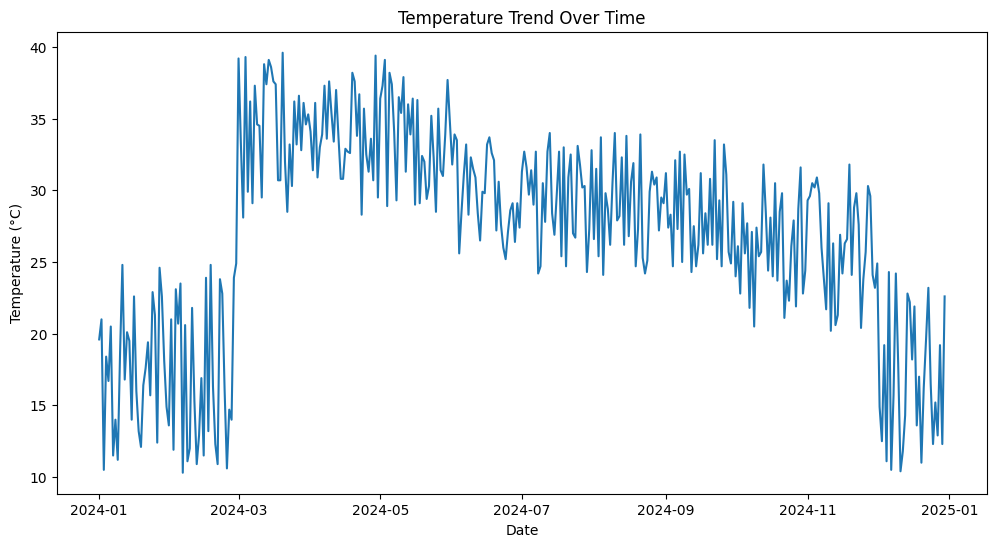

In [ ]:
plt.plot(df['Date'], df['Temperature'])

plt.title("Temperature Trend Over Time")

plt.xlabel("Date")

plt.ylabel("Temperature (°C)")

plt.show()

In [ ]:
import os

os.makedirs('visualizations', exist_ok=True)

plt.savefig(
    'visualizations/temperature_trend.png'
)

<Figure size 1200x600 with 0 Axes>

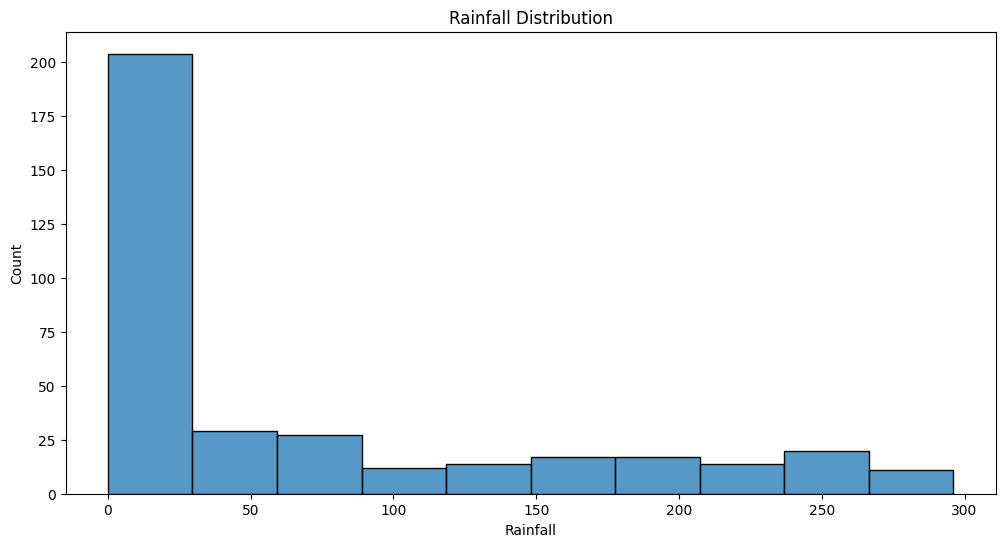

In [ ]:
sns.histplot(df['Rainfall'])

plt.title("Rainfall Distribution")

plt.xlabel("Rainfall")

plt.show()

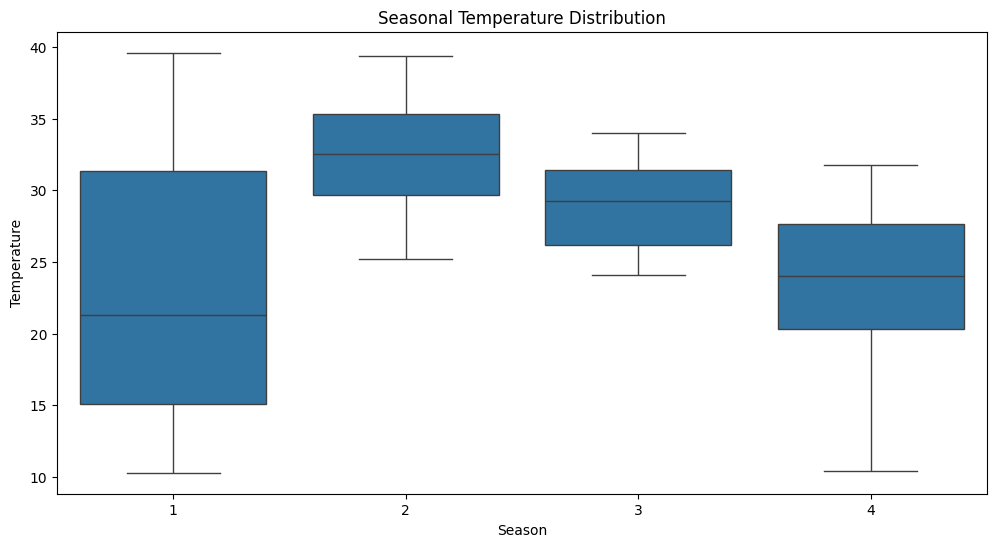

In [ ]:
sns.boxplot(
    x='Season',
    y='Temperature',
    data=df
)

plt.title("Seasonal Temperature Distribution")

plt.show()

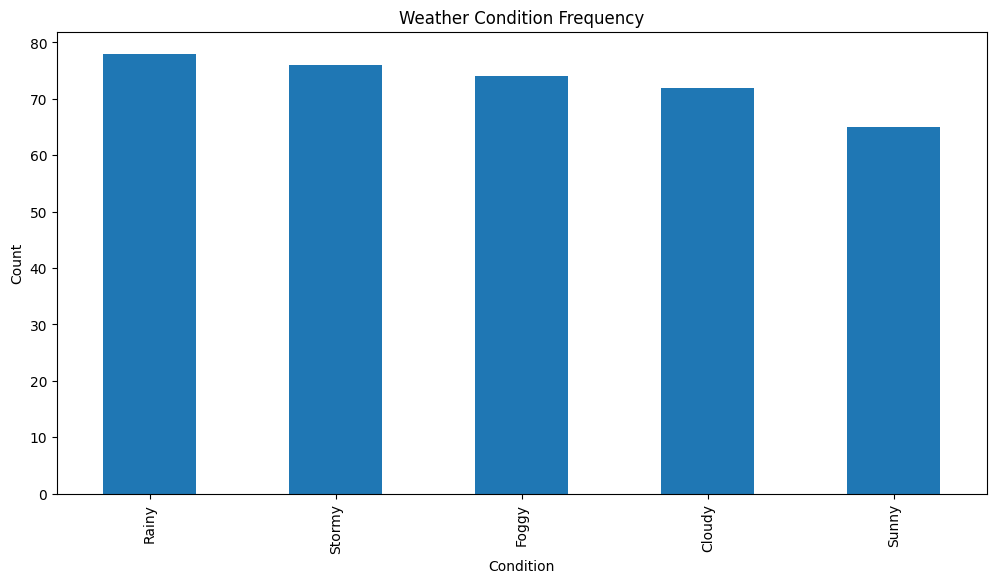

In [ ]:
weather_counts = (
    df['Weather_Condition']
    .value_counts()
)

weather_counts.plot(kind='bar')

plt.title("Weather Condition Frequency")

plt.xlabel("Condition")

plt.ylabel("Count")

plt.show()

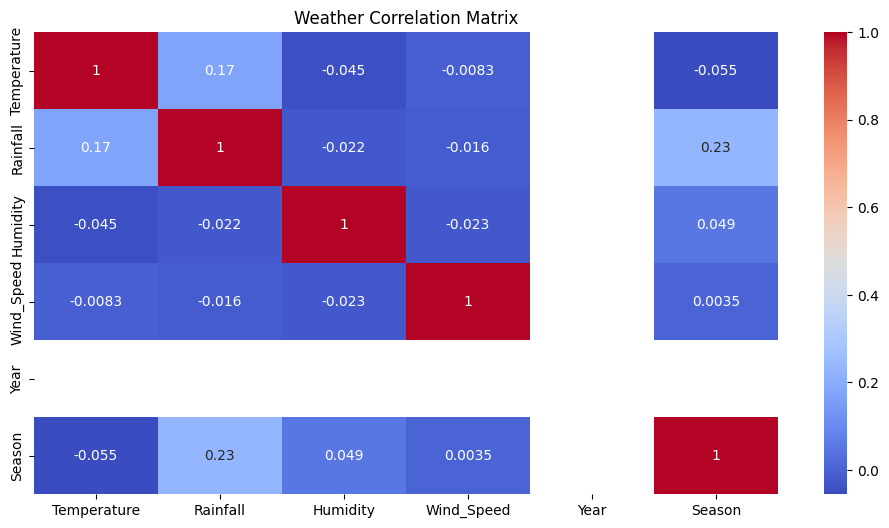

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title("Weather Correlation Matrix")

plt.show()

In [ ]:
hottest_days = df.sort_values(
    by='Temperature',
    ascending=False
).head(10)

print(hottest_days)

          Date  Temperature  Rainfall  Humidity  Wind_Speed Weather_Condition  \
79  2024-03-20         39.6       5.6        81        11.2             Foggy   
119 2024-04-29         39.4       4.0        41        13.2            Cloudy   
63  2024-03-04         39.3       2.7        47        18.0             Foggy   
60  2024-03-01         39.2      17.6        55         8.7            Cloudy   
123 2024-05-03         39.1      11.5        64         9.1            Cloudy   
73  2024-03-14         39.1       4.7        50        19.6            Cloudy   
71  2024-03-12         38.8       4.2        55        14.0             Rainy   
74  2024-03-15         38.6       0.5        87        18.6            Stormy   
125 2024-05-05         38.2      12.0        47        16.3             Foggy   
109 2024-04-19         38.2      19.1        66        11.7             Foggy   

     Month  Year  Season  
79   March  2024       1  
119  April  2024       2  
63   March  2024       1  


In [ ]:
rainiest_days = df.sort_values(
    by='Rainfall',
    ascending=False
).head(10)

print(rainiest_days)

          Date  Temperature  Rainfall  Humidity  Wind_Speed Weather_Condition  \
264 2024-09-21         26.2     296.1        43         2.1             Rainy   
175 2024-06-24         25.2     293.3        78        16.4            Cloudy   
171 2024-06-20         27.2     292.5        65        17.6             Sunny   
228 2024-08-16         26.8     292.1        94        16.8             Sunny   
215 2024-08-03         25.4     291.6        95        14.2            Stormy   
271 2024-09-28         25.7     286.9        69        17.0             Rainy   
201 2024-07-20         24.7     286.3        77         7.4            Stormy   
238 2024-08-26         31.3     277.2        82        11.4            Stormy   
209 2024-07-28         30.3     275.9        81         2.7            Stormy   
180 2024-06-29         29.1     269.8        95         3.3            Stormy   

         Month  Year  Season  
264  September  2024       3  
175       June  2024       2  
171       June 

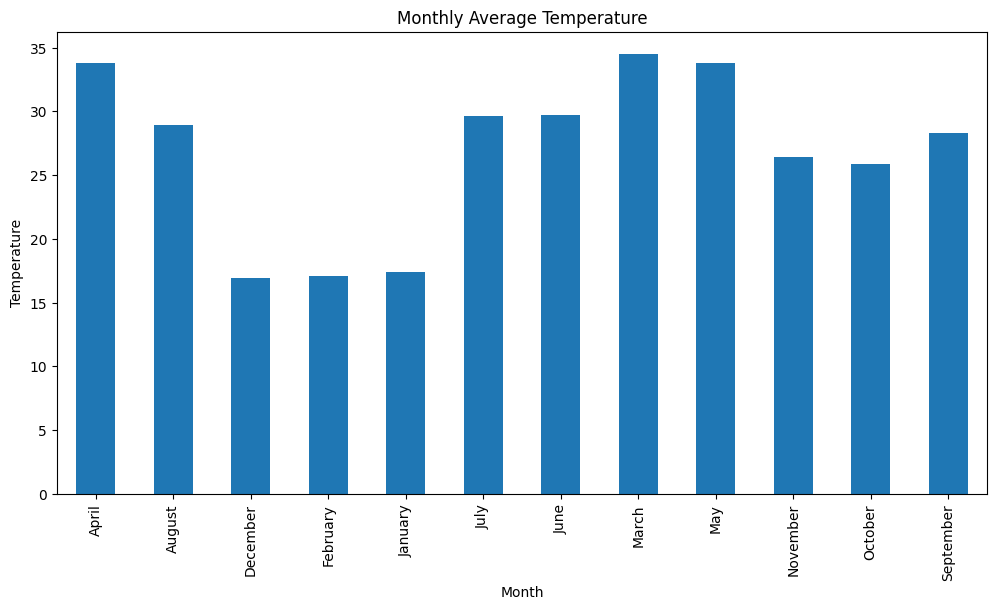

In [ ]:
monthly_temp = (
    df.groupby('Month')['Temperature']
    .mean()
)

monthly_temp.plot(kind='bar')

plt.title("Monthly Average Temperature")

plt.ylabel("Temperature")

plt.show()

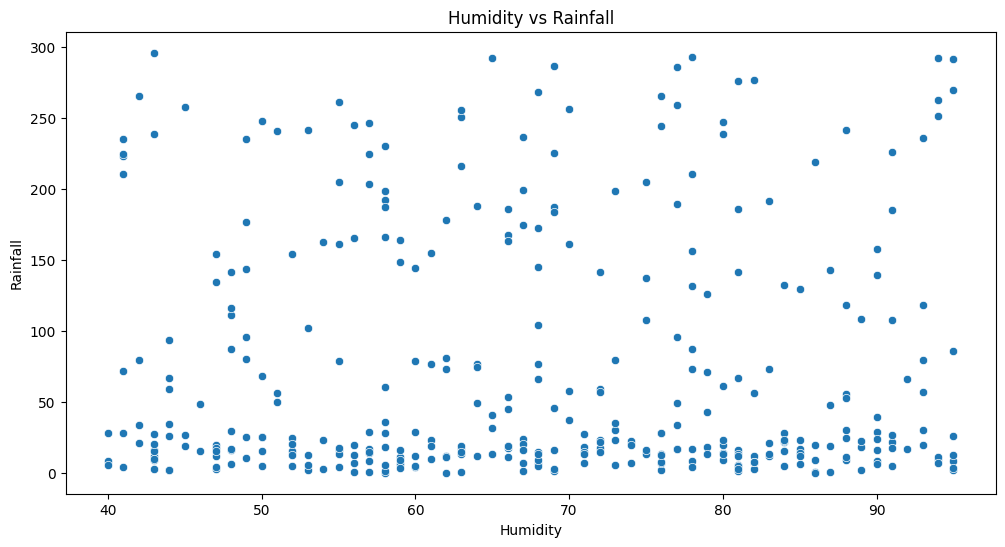

In [ ]:
sns.scatterplot(
    x='Humidity',
    y='Rainfall',
    data=df
)

plt.title("Humidity vs Rainfall")

plt.show()

In [ ]:
avg_temp = df['Temperature'].mean()

print("Average Temperature:", avg_temp)

Average Temperature: 26.927671232876712


In [ ]:
max_rainfall = df['Rainfall'].max()

print("Maximum Rainfall:", max_rainfall)

Maximum Rainfall: 296.1


In [ ]:
corr = df['Humidity'].corr(df['Rainfall'])

print("Correlation:", corr)

Correlation: -0.022410422053426977


In [ ]:
import os

os.makedirs('reports', exist_ok=True)

report = f"""
WEATHER DATA ANALYSIS REPORT
============================

Average Temperature: {round(avg_temp,2)} °C

Maximum Rainfall: {round(max_rainfall,2)} mm

KEY INSIGHTS:
1. Rainfall peaks during monsoon months.
2. Humidity strongly impacts rainfall.
3. Seasonal weather patterns are clearly visible.
4. Summer records highest temperatures.
"""

with open(
    'reports/weather_report.txt',
    'w'
) as file:

    file.write(report)

print("Weather report generated successfully!")

Weather report generated successfully!


In [ ]:
df['7_Day_Temp_Avg'] = (
    df['Temperature']
    .rolling(7)
    .mean()
)

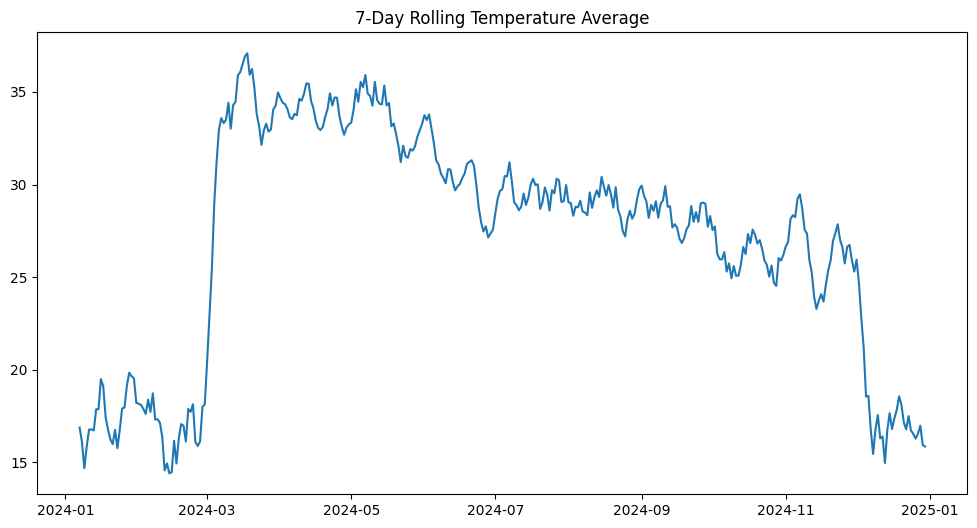

In [ ]:
plt.plot(df['Date'], df['7_Day_Temp_Avg'])

plt.title("7-Day Rolling Temperature Average")

plt.show()

<Axes: xlabel='Weather_Condition', ylabel='Month'>

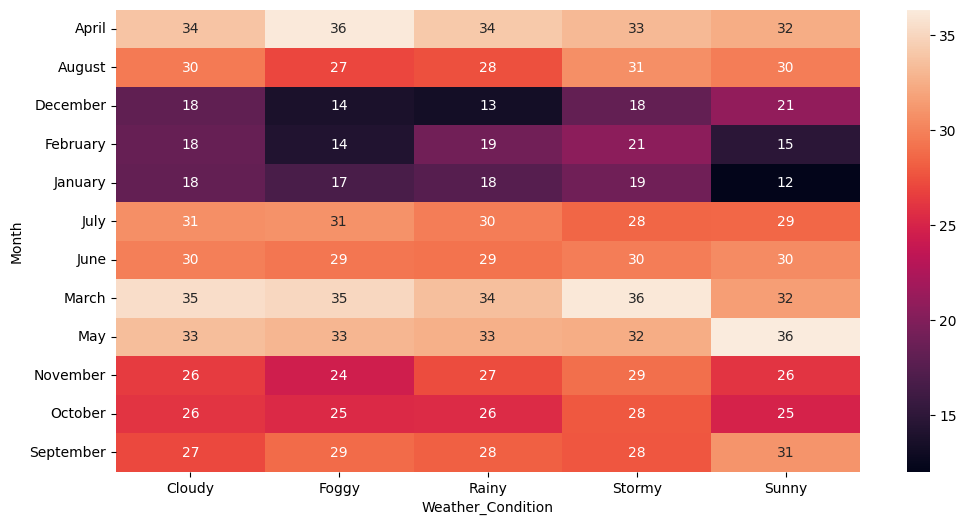

In [ ]:
pivot = df.pivot_table(
    values='Temperature',
    index='Month',
    columns='Weather_Condition',
    aggfunc='mean'
)

sns.heatmap(pivot, annot=True)

In [ ]:
extreme_heat = df[df['Temperature'] > 38]

print(extreme_heat)

          Date  Temperature  Rainfall  Humidity  Wind_Speed Weather_Condition  \
60  2024-03-01         39.2      17.6        55         8.7            Cloudy   
63  2024-03-04         39.3       2.7        47        18.0             Foggy   
71  2024-03-12         38.8       4.2        55        14.0             Rainy   
73  2024-03-14         39.1       4.7        50        19.6            Cloudy   
74  2024-03-15         38.6       0.5        87        18.6            Stormy   
79  2024-03-20         39.6       5.6        81        11.2             Foggy   
109 2024-04-19         38.2      19.1        66        11.7             Foggy   
119 2024-04-29         39.4       4.0        41        13.2            Cloudy   
123 2024-05-03         39.1      11.5        64         9.1            Cloudy   
125 2024-05-05         38.2      12.0        47        16.3             Foggy   

     Month  Year  Season  7_Day_Temp_Avg  
60   March  2024       1       20.485714  
63   March  2024      